# TCRdist Analysis

This notebook demonstrates the custom mirpy TCRdist implementation:

1. **Data loading** — GILGFVFTL influenza-specific TRB sequences
2. **TCRdist computation** — pairwise distance matrix
3. **Radius analysis** — per-clonotype neighbourhood size
4. **Metaclonotype discovery** — radius-threshold clustering
5. **Visualisation** — distance heatmap, UMAP, sequence trees
6. **Motif logos** — CDR3 position-weight matrices with OLGA background

Reproduces the spirit of:  
https://tcrdist3.readthedocs.io/en/latest/influenza_example.html  
https://tcrdist3.readthedocs.io/en/latest/visualizing.html  
https://tcrdist3.readthedocs.io/en/latest/motif_gallery.html  
https://tcrdist3.readthedocs.io/en/latest/tree.html

All code uses only mirpy internals — no tcrdist3 imports.

In [1]:
# Cell 1 — environment versions
import sys, platform
import numpy as np
import polars as pl

print(f"Python  {sys.version}")
print(f"NumPy   {np.__version__}")
print(f"Polars  {pl.__version__}")
print(f"Arch    {platform.machine()}")

Python  3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:07:49) [Clang 20.1.8 ]
NumPy   1.26.4
Polars  1.40.1
Arch    arm64


In [2]:
# Cell 2 — imports and paths
import time
import gzip
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np
import polars as pl

warnings.filterwarnings("ignore")

REPO_ROOT = Path(".").resolve().parent
AIRR_ROOT = REPO_ROOT / "airr_benchmark" / "tcrdist"
ASSETS    = REPO_ROOT / "tests" / "assets"

# Matplotlib journal style
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Imports OK")

Imports OK


## 1. Data Loading

Load GILGFVFTL-associated TRB clonotypes from the airr_benchmark dataset.  
Falls back to the bundled test asset if the HuggingFace download is not present.

In [3]:
# Cell 3 — load sequence data
from mir.common.clonotype import Clonotype
from mir.common.repertoire import LocusRepertoire

def _open(path):
    return gzip.open(path, "rt") if str(path).endswith(".gz") else open(path)

def load_clonotypes(path: Path, sep="\t") -> list[Clonotype]:
    """Parse a flat TSV/CSV with flexible column names."""
    result = []
    with _open(path) as fh:
        header = [c.lower().strip() for c in fh.readline().split(sep)]
        col = {c: i for i, c in enumerate(header)}
        junc_key = next((k for k in ("junction_aa","cdr3","cdr3_aa") if k in col), None)
        v_key    = next((k for k in ("v_gene","v_call","v_b_gene") if k in col), None)
        j_key    = next((k for k in ("j_gene","j_call","j_b_gene") if k in col), None)
        cnt_key  = next((k for k in ("count","duplicate_count","frequency") if k in col), None)
        for i, line in enumerate(fh):
            p = line.strip().split(sep)
            if not p or not junc_key:
                continue
            junc = p[col[junc_key]].strip() if junc_key else ""
            if not junc:
                continue
            v    = p[col[v_key]].strip() if v_key and col[v_key] < len(p) else ""
            j    = p[col[j_key]].strip() if j_key and col[j_key] < len(p) else ""
            cnt  = 1
            if cnt_key and col[cnt_key] < len(p):
                try: cnt = int(float(p[col[cnt_key]]))
                except: pass
            result.append(Clonotype(
                sequence_id=f"seq_{i:05d}", junction_aa=junc,
                v_gene=v, j_gene=j, duplicate_count=cnt, locus="TRB",
            ))
    return result

def load_bare_sequences(path: Path) -> list[Clonotype]:
    """Parse a bare file with one junction_aa per line (no header)."""
    result = []
    with _open(path) as fh:
        for i, line in enumerate(fh):
            junc = line.strip()
            if junc:
                result.append(Clonotype(
                    sequence_id=f"seq_{i:05d}", junction_aa=junc, locus="TRB",
                ))
    return result

# Try local files first, then bundled asset (bare sequences), then HuggingFace
_candidates = [
    (AIRR_ROOT / "gilgfvftl_trb_junctions.tsv",  "tsv"),
    (AIRR_ROOT / "gilgfvftl_trb_junctions.csv",  "csv"),
    (ASSETS    / "gilgfvftl_trb_junctions.txt.gz", "bare"),
]
clonotypes = None
for p, fmt in _candidates:
    if p.exists():
        if fmt == "bare":
            clonotypes = load_bare_sequences(p)
        else:
            sep = "\t" if fmt == "tsv" else ","
            clonotypes = load_clonotypes(p, sep=sep)
        print(f"Loaded from {p.name}: {len(clonotypes)} clonotypes")
        break

if clonotypes is None:
    try:
        from huggingface_hub import hf_hub_download
        _p = hf_hub_download(
            repo_id="isalgo/airr_benchmark",
            filename="tcrdist/gilgfvftl_trb_junctions.tsv",
            repo_type="dataset",
            local_dir=str(AIRR_ROOT.parent),
        )
        clonotypes = load_clonotypes(Path(_p), sep="\t")
        print(f"Downloaded from HuggingFace: {len(clonotypes)} clonotypes")
    except Exception as e:
        print(f"HuggingFace unavailable ({e}); using synthetic data")

if clonotypes is None:
    _seqs = [
        ("CASSIRSSYEQYF","TRBV19*01","TRBJ2-7*01",100),
        ("CASSIRSYEQYF", "TRBV19*01","TRBJ2-7*01",80),
        ("CASSIRASYEQYF","TRBV19*01","TRBJ2-7*01",60),
        ("CASSIRGSSYEQYF","TRBV19*01","TRBJ2-7*01",40),
        ("CASSIRASSYEQYF","TRBV19*01","TRBJ2-7*01",30),
        ("CASSIRSSYEQYF","TRBV19*01","TRBJ1-5*01",20),
        ("CASSIRSSSYEQYF","TRBV19*01","TRBJ2-7*01",15),
        ("CASSLGQGANVLTF","TRBV5-1*01","TRBJ2-6*01",10),
        ("CASSYRGNTEAFF","TRBV20-1*01","TRBJ1-1*01",5),
        ("CASSGAGGREQYF","TRBV2*01","TRBJ2-7*01",3),
    ]
    clonotypes = [
        Clonotype(sequence_id=f"s{i}", junction_aa=j, v_gene=v,
                  j_gene=g, duplicate_count=c, locus="TRB")
        for i,(j,v,g,c) in enumerate(_seqs)
    ]
    print(f"Using {len(clonotypes)} synthetic GILGFVFTL sequences")

rep = LocusRepertoire(clonotypes=clonotypes, locus="TRB")
print(f"\nRepertoire: {len(clonotypes)} clonotypes, locus=TRB")

Loaded from gilgfvftl_trb_junctions.txt.gz: 5236 clonotypes

Repertoire: 5236 clonotypes, locus=TRB


In [4]:
# Cell 4 — quick data summary
df = pl.DataFrame({
    "junction_aa": [c.junction_aa for c in clonotypes],
    "v_gene": [c.v_gene for c in clonotypes],
    "j_gene": [c.j_gene for c in clonotypes],
    "length": [len(c.junction_aa) for c in clonotypes],
    "count": [c.duplicate_count for c in clonotypes],
})
print("V gene distribution:")
print(df.group_by("v_gene").agg(pl.len().alias("n")).sort("n", descending=True))
print("\nCDR3 length distribution:")
print(df.group_by("length").agg(pl.len().alias("n")).sort("length"))

V gene distribution:
shape: (1, 2)
┌────────┬──────┐
│ v_gene ┆ n    │
│ ---    ┆ ---  │
│ str    ┆ u32  │
╞════════╪══════╡
│        ┆ 5236 │
└────────┴──────┘

CDR3 length distribution:
shape: (24, 2)
┌────────┬─────┐
│ length ┆ n   │
│ ---    ┆ --- │
│ i64    ┆ u32 │
╞════════╪═════╡
│ 6      ┆ 1   │
│ 7      ┆ 2   │
│ 8      ┆ 2   │
│ 9      ┆ 4   │
│ 10     ┆ 34  │
│ …      ┆ …   │
│ 25     ┆ 1   │
│ 26     ┆ 1   │
│ 27     ┆ 1   │
│ 33     ┆ 1   │
│ 38     ┆ 1   │
└────────┴─────┘


## 2. Build TcrDist Model

In [5]:
# Cell 5 — build TcrDist
from mir.distances.tcrdist import TcrDist

t0 = time.perf_counter()
td = TcrDist.from_defaults(
    "TRB", "human",
    w_v=1.0,
    w_j=0.0,
    w_cdr3=3.0,
    fixed_gaps=(3, 4, -4, -3),   # C-accelerated JunctionAligner
)
print(f"TcrDist built in {time.perf_counter()-t0:.2f}s")
print(f"  locus={td.locus}, species={td.species}")
print(f"  weights: w_v={td.w_v}, w_j={td.w_j}, w_cdr3={td.w_cdr3}")
print(f"  fixed_gaps={td.fixed_gaps}")

TcrDist built in 0.35s
  locus=TRB, species=human
  weights: w_v=1.0, w_j=0.0, w_cdr3=3.0
  fixed_gaps=(3, 4, -4, -3)


## 3. Pairwise Distance Matrix

In [6]:
# Cell 6 — subsample 100 representative clonotypes, compute pairwise distance matrix
rng = np.random.default_rng(42)
N_sub = min(100, len(clonotypes))
sub_idx = sorted(rng.choice(len(clonotypes), size=N_sub, replace=False).tolist())
clonotypes_sub = [clonotypes[i] for i in sub_idx]
N = len(clonotypes_sub)
print(f"Subsampled {N} clonotypes for distance analysis (from {len(clonotypes)} total)")

t0 = time.perf_counter()
dist_mat = td.self_dist_matrix(clonotypes_sub, n_jobs=1)
wall = time.perf_counter() - t0

n_pairs = N * (N-1) // 2
print(f"N={N}, {n_pairs:,} pairs  |  {wall:.3f}s  ({n_pairs/wall:,.0f} pairs/s)")

off_diag = dist_mat[dist_mat > 0]
if len(off_diag):
    print(f"Distance range: [{off_diag.min():.1f}, {dist_mat.max():.1f}]")


Subsampled 100 clonotypes for distance analysis (from 5236 total)
N=100, 4,950 pairs  |  0.000s  (10,255,539 pairs/s)
Distance range: [480.0, 6120.0]


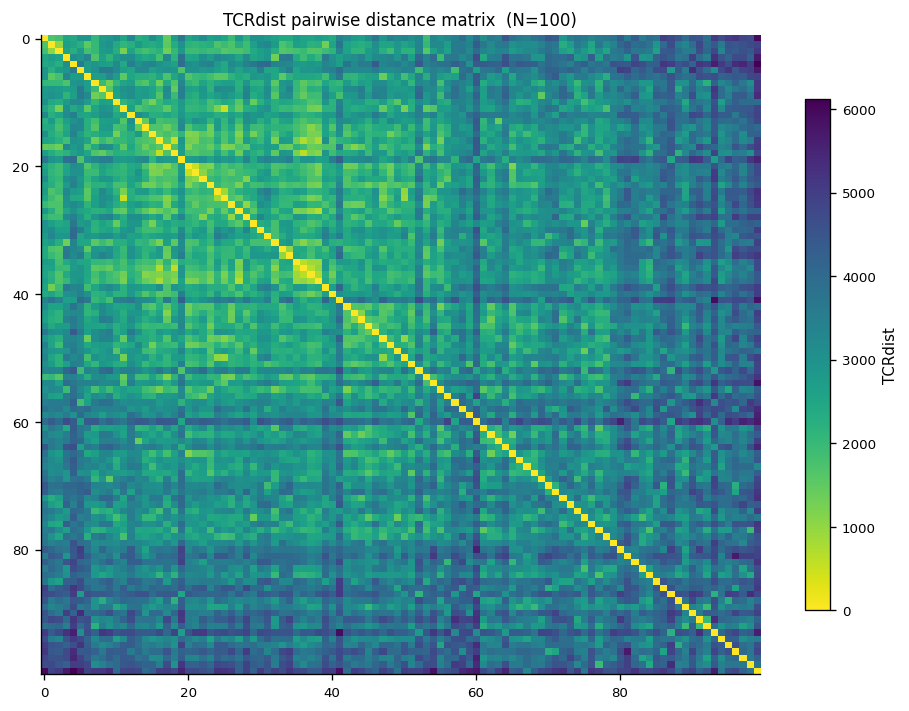

In [7]:
# Cell 7 — distance heatmap (100-clonotype subsample)
sort_idx = sorted(
    range(N),
    key=lambda i: (clonotypes_sub[i].v_gene or "", len(clonotypes_sub[i].junction_aa or ""))
)
mat_sorted = dist_mat[np.ix_(sort_idx, sort_idx)]
labels_sorted = [
    (clonotypes_sub[i].junction_aa[:12] + "..." if len(clonotypes_sub[i].junction_aa or "") > 12
     else (clonotypes_sub[i].junction_aa or "?"))
    for i in sort_idx
]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(mat_sorted, cmap="viridis_r", aspect="auto")
plt.colorbar(im, ax=ax, label="TCRdist", shrink=0.8)

if N <= 40:
    ax.set_xticks(range(N))
    ax.set_xticklabels(labels_sorted, rotation=90, fontsize=6)
    ax.set_yticks(range(N))
    ax.set_yticklabels(labels_sorted, fontsize=6)

ax.set_title(f"TCRdist pairwise distance matrix  (N={N})", fontsize=10)
fig.tight_layout()
plt.show()


## 4. Radius Analysis

Following tcrdist3 convention, each clonotype is assigned a *radius*: the
median (50th-percentile) distance to all other sequences in the repertoire.
Sequences with small radii are in dense neighbourhoods — indicative of
convergent antigen-driven selection.

In [8]:
# Cell 8 — compute radii on the 100-clonotype subsample
radii = td.compute_radius(clonotypes_sub, clonotypes_sub, percentile=50, n_jobs=1)

print(f"Radius statistics (N={N}):")
print(f"  Min:    {radii.min():.2f}")
print(f"  Median: {np.median(radii):.2f}")
print(f"  Mean:   {radii.mean():.2f}")
print(f"  Max:    {radii.max():.2f}")

top_idx = np.argsort(radii)[:5]
print("\nSmallest-radius (most convergent) sequences:")
print(f"{'junction_aa':22s}  {'v_gene':15s}  {'radius':>8s}")
for i in top_idx:
    c = clonotypes_sub[i]
    print(f"{c.junction_aa:22s}  {c.v_gene or '':15s}  {radii[i]:8.2f}")


Radius statistics (N=100):
  Min:    2265.00
  Median: 2970.00
  Mean:   3101.40
  Max:    4815.00

Smallest-radius (most convergent) sequences:
junction_aa             v_gene             radius
CASSLAAGAEQYF                             2265.00
CASSTRSSSEQYF                             2355.00
CASSIVSGDEQFF                             2370.00
CASSVRASDEQYF                             2430.00
CASSIRSGTEAFF                             2460.00


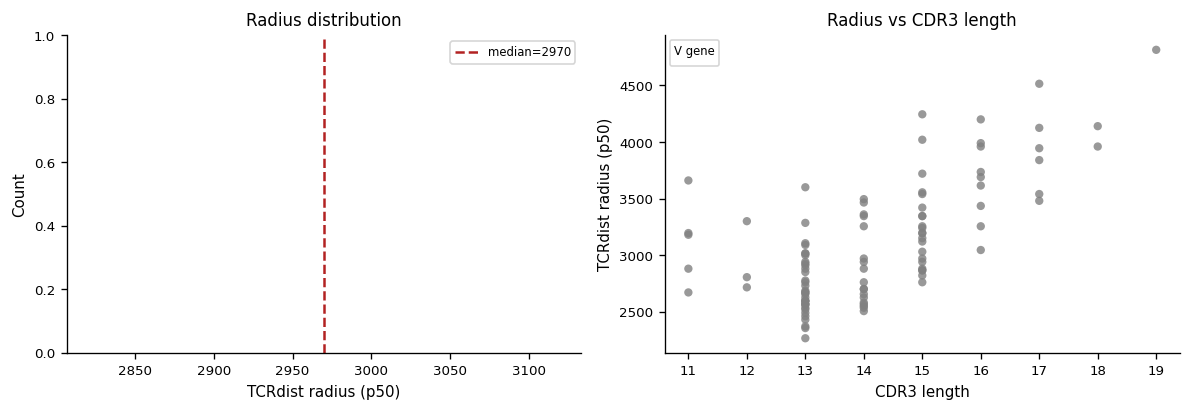

In [9]:
# Cell 9 — radius distribution and radius vs CDR3 length
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

v_colors = {
    v: plt.cm.tab10(i % 10)
    for i, v in enumerate(sorted(set(c.v_gene for c in clonotypes_sub if c.v_gene)))
}

# Left: radius histogram coloured by V gene
ax = axes[0]
for v, col in v_colors.items():
    vr = [radii[i] for i, c in enumerate(clonotypes_sub) if c.v_gene == v]
    ax.hist(vr, bins=20, alpha=0.6, color=col, label=v.split("*")[0], edgecolor="none")
ax.axvline(float(np.median(radii)), color="firebrick", lw=1.5, ls="--",
           label=f"median={np.median(radii):.0f}")
ax.set_xlabel("TCRdist radius (p50)"); ax.set_ylabel("Count")
ax.set_title("Radius distribution")
ax.legend(fontsize=7, ncol=2)

# Right: radius vs CDR3 length (coloured by V gene)
ax = axes[1]
lengths = np.array([len(c.junction_aa or "") for c in clonotypes_sub])
for i, c in enumerate(clonotypes_sub):
    col = v_colors.get(c.v_gene, "grey")
    ax.scatter(lengths[i], radii[i], color=col, s=25, alpha=0.8, edgecolors="none")
from matplotlib.patches import Patch
handles = [Patch(color=v, label=k.split("*")[0]) for k, v in list(v_colors.items())[:8]]
ax.legend(handles=handles, fontsize=6, title="V gene", title_fontsize=7)
ax.set_xlabel("CDR3 length"); ax.set_ylabel("TCRdist radius (p50)")
ax.set_title("Radius vs CDR3 length")

fig.tight_layout()
plt.show()


## 5. Metaclonotype Discovery

Cluster clonotypes into meta-clonotypes using the median radius as the
neighbourhood threshold.  Each cluster is seeded by a representative sequence
and contains all repertoire members within `max_distance`.

In [10]:
# Cell 10 — find metaclonotypes
from mir.common.metaclonotype import summarize_metaclonotypes

# Use 25th-percentile radius as threshold (captures tight convergent clusters)
max_dist = float(np.percentile(radii, 50)) + 1.0
print(f"Using max_distance = {max_dist:.2f}")

t0 = time.perf_counter()
meta = td.find_metaclonotypes(
    rep,
    max_distance=max_dist,
    n_jobs=1,
)
print(f"Found {meta.n_clusters} metaclonotypes in {time.perf_counter()-t0:.3f}s")

summary = summarize_metaclonotypes(rep, meta)
print("\nTop 10 metaclonotypes by cluster size:")
print(summary.sort("n_members", descending=True).head(10).select(
    ["cluster_id","n_members","representative_junction_aa","representative_v_gene","duplicate_count"]
))

Using max_distance = 2971.00


Found 5236 metaclonotypes in 7.434s

Top 10 metaclonotypes by cluster size:
shape: (10, 5)
┌─────────────────┬───────────┬──────────────────────────┬───────────────────────┬─────────────────┐
│ cluster_id      ┆ n_members ┆ representative_junction_ ┆ representative_v_gene ┆ duplicate_count │
│ ---             ┆ ---       ┆ aa                       ┆ ---                   ┆ ---             │
│ str             ┆ u32       ┆ ---                      ┆ str                   ┆ i64             │
│                 ┆           ┆ str                      ┆                       ┆                 │
╞═════════════════╪═══════════╪══════════════════════════╪═══════════════════════╪═════════════════╡
│ tcrdist_mc_3623 ┆ 4040      ┆ CASSSGSNNEQFF            ┆                       ┆ 0               │
│ tcrdist_mc_2465 ┆ 4014      ┆ CASSLSGAAEQYF            ┆                       ┆ 0               │
│ tcrdist_mc_1813 ┆ 4005      ┆ CASSISGGSEQFF            ┆                       ┆ 0               │


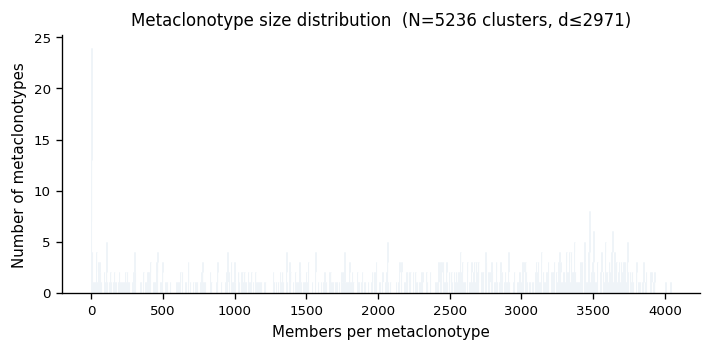

In [11]:
# Cell 11 — metaclonotype size distribution
sizes = summary["n_members"].to_list()
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(sizes, bins=range(1, max(sizes)+2), color="steelblue", edgecolor="white", linewidth=0.5, align="left")
ax.set_xlabel("Members per metaclonotype")
ax.set_ylabel("Number of metaclonotypes")
ax.set_title(f"Metaclonotype size distribution  (N={meta.n_clusters} clusters, d≤{max_dist:.0f})")
fig.tight_layout()
plt.show()

## 6. UMAP Visualisation

Embed the distance matrix in 2D via UMAP.  Points coloured by V gene.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


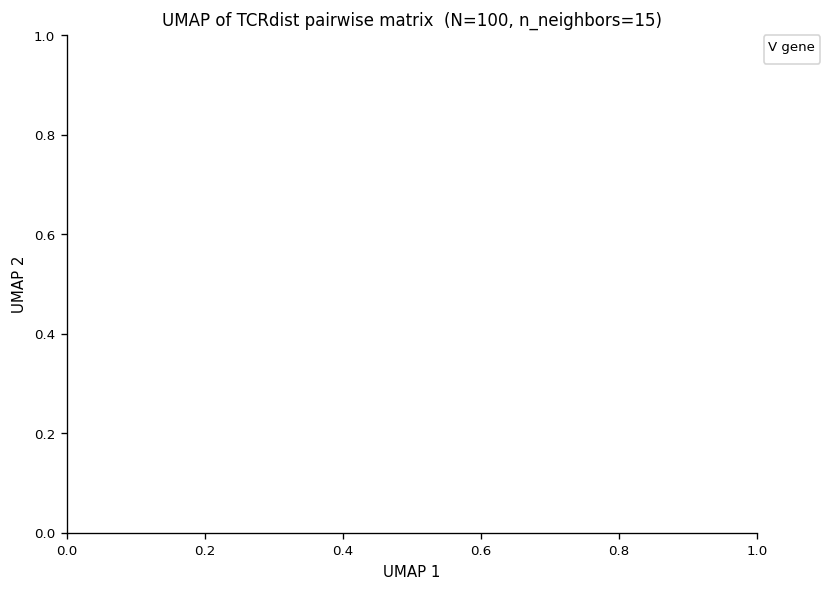

In [12]:
# Cell 12 — UMAP of 100-clonotype subsample (precomputed TCRdist matrix)
try:
    from umap import UMAP
    _has_umap = True
except ImportError:
    _has_umap = False
    print("umap-learn not installed; skipping UMAP.  Install with: pip install umap-learn")

if _has_umap and N >= 5:
    n_neighbors = min(N - 1, 15)
    reducer = UMAP(
        metric="precomputed",
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=0.2,
        random_state=42,
    )
    embedding = reducer.fit_transform(dist_mat)

    unique_v = sorted(set(c.v_gene for c in clonotypes_sub if c.v_gene))
    palette = plt.cm.tab10
    v_col = {v: palette(i % 10) for i, v in enumerate(unique_v)}

    fig, ax = plt.subplots(figsize=(7, 5))
    for v in unique_v:
        idx = [i for i, c in enumerate(clonotypes_sub) if c.v_gene == v]
        ax.scatter(
            embedding[idx, 0], embedding[idx, 1],
            s=35,
            color=v_col[v], alpha=0.85, edgecolors="white", linewidth=0.3,
            label=v.split("*")[0],
        )

    ax.legend(fontsize=7, title="V gene", title_fontsize=8, markerscale=1.5,
              bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.set_title(f"UMAP of TCRdist pairwise matrix  (N={N}, n_neighbors={n_neighbors})")
    fig.tight_layout()
    plt.show()
elif N < 5:
    print("Too few sequences for UMAP; load more data.")


## 7. Hierarchical Clustering Tree

Visualise the distance structure as a dendrogram (analogous to the TCRdist3
tree visualisation).  Uses `scipy.cluster.hierarchy`.

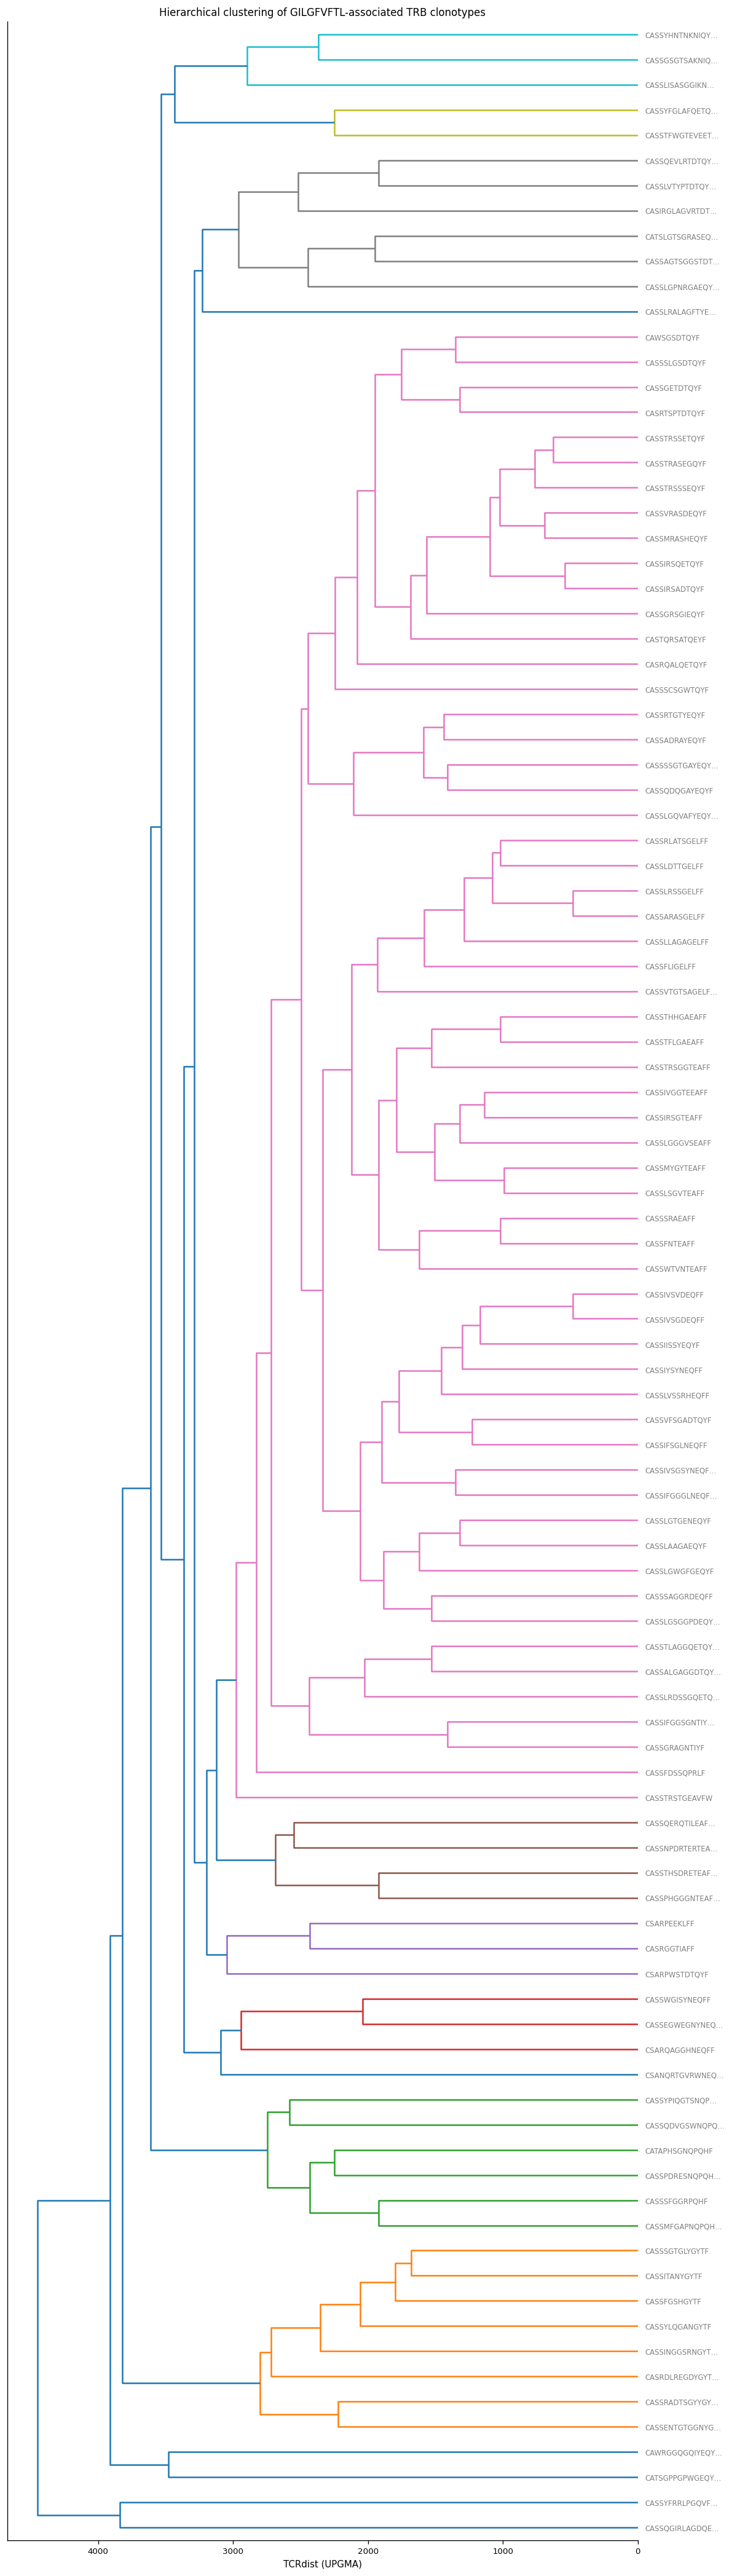

In [13]:
# Cell 13 — hierarchical clustering dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Convert symmetric matrix to condensed form
condensed = squareform(dist_mat)
Z = linkage(condensed, method="average")

# Labels: junction_aa (truncated) coloured by V gene
leaf_labels = [
    (c.junction_aa or "?")[:14] + ("…" if len(c.junction_aa or "") > 14 else "")
    for c in clonotypes_sub
]
unique_v = sorted(set(c.v_gene for c in clonotypes_sub if c.v_gene))
v_col_hex = {v: f"C{i%10}" for i, v in enumerate(unique_v)}
leaf_colors = [v_col_hex.get(c.v_gene, "grey") for c in clonotypes_sub]

fig_h = max(5, 0.35 * N)
fig, ax = plt.subplots(figsize=(10, fig_h))
dg = dendrogram(
    Z, ax=ax, labels=leaf_labels,
    orientation="left", leaf_font_size=7,
    color_threshold=0.5 * float(np.max(dist_mat)),
)
# Colour leaf labels by V gene
for lbl, col in zip(ax.get_ymajorticklabels(), [leaf_colors[i] for i in dg["leaves"]]):
    lbl.set_color(col)

ax.set_xlabel("TCRdist (UPGMA)")
ax.set_title("Hierarchical clustering of GILGFVFTL-associated TRB clonotypes")
fig.tight_layout()
plt.show()

## 8. CDR3 Motif Logos

Build IC and selection logos for the largest metaclonotype clusters using
`mir.biomarkers.motif_logo` with an OLGA background for the same V/J/length.

In [14]:
# Cell 14 — load motif_pwms for OLGA background
from mir.biomarkers.motif_logo import (
    compute_pwm, compute_logo, get_vj_background,
    load_motif_pwms, plot_logo, BIOCHEMISTRY_COLORS,
)

# Try loading motif_pwms.txt.gz from airr_benchmark/vdjdb/
_pwms_candidates = [
    REPO_ROOT / "airr_benchmark" / "vdjdb" / "motif_pwms.txt.gz",
    REPO_ROOT / "airr_benchmark" / "vdjdb" / "motif_pwms.txt",
]
pwms = None
for _p in _pwms_candidates:
    if _p.exists():
        pwms = load_motif_pwms(str(_p))
        print(f"Loaded motif_pwms from {_p.name}: {pwms['cid'].n_unique()} clusters")
        break

if pwms is None:
    print("motif_pwms.txt.gz not found; logos will show IC only (no background subtraction)")
    print("To download: huggingface-cli download isalgo/airr_benchmark vdjdb/motif_pwms.txt.gz --repo-type dataset")

motif_pwms.txt.gz not found; logos will show IC only (no background subtraction)
To download: huggingface-cli download isalgo/airr_benchmark vdjdb/motif_pwms.txt.gz --repo-type dataset


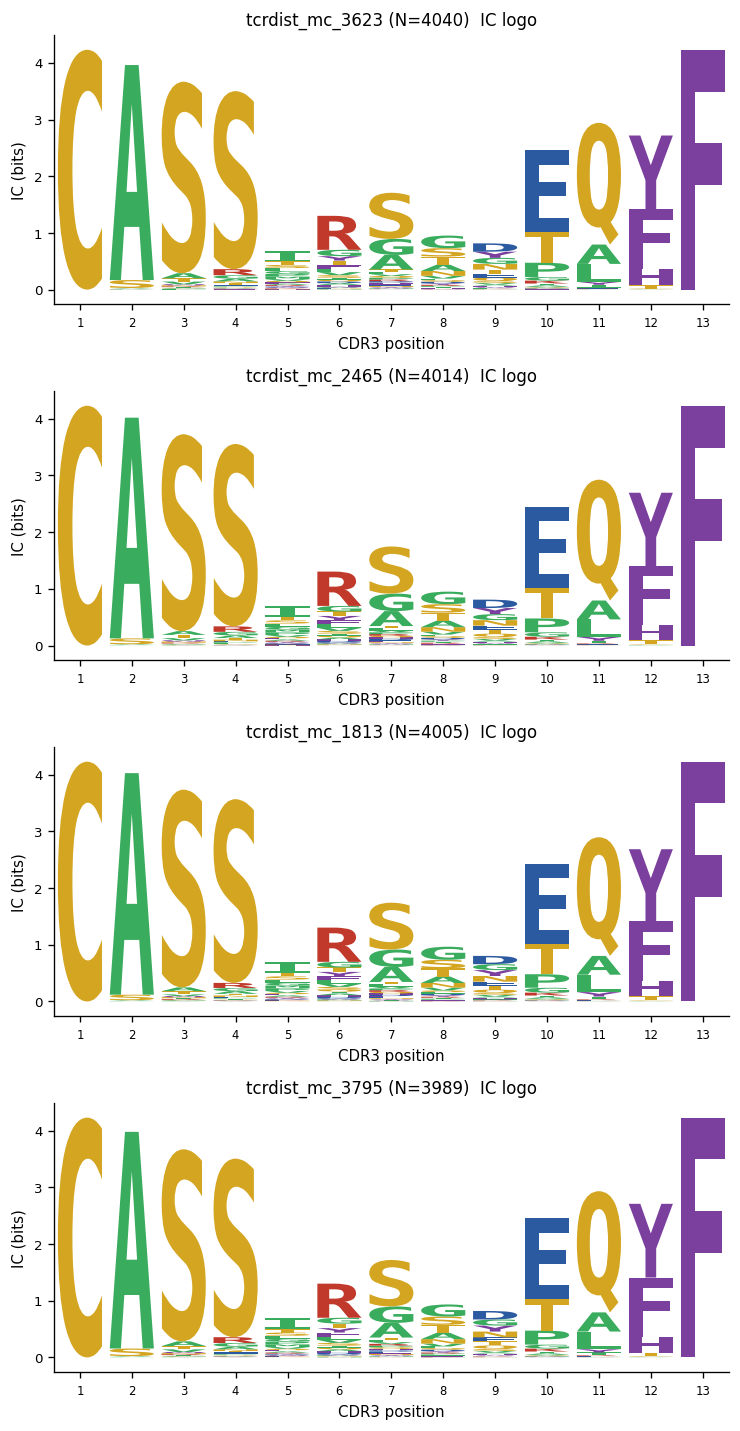

In [15]:
# Cell 15 — build logos for top metaclonotype clusters
from mir.common.metaclonotype import metaclonotype_junctions

top_clusters = (
    summary.sort("n_members", descending=True)
    .head(4)["cluster_id"].to_list()
)

fig, axes = plt.subplots(
    len(top_clusters), 2,
    figsize=(12, 3 * len(top_clusters)),
)
if len(top_clusters) == 1:
    axes = axes[np.newaxis, :]

for row_ax, cid in zip(axes, top_clusters):
    junctions = metaclonotype_junctions(rep, meta, cluster_id=cid)
    n_seqs = len(junctions)

    if n_seqs < 2:
        row_ax[0].text(0.5, 0.5, f"{cid}: {n_seqs} seq(s) — skip",
                       ha="center", va="center", transform=row_ax[0].transAxes)
        row_ax[1].set_visible(False)
        continue

    pwm  = compute_pwm(junctions, pseudocount=0.5)
    logo = compute_logo(pwm)

    # Try to add OLGA background
    bg = None
    if pwms is not None:
        rep_rows = summary.filter(pl.col("cluster_id") == cid)
        rv = rep_rows["representative_v_gene"][0] if len(rep_rows) else None
        rj = rep_rows["representative_j_gene"][0] if len(rep_rows) else None
        modal_len = pwm["pos"].n_unique() if len(pwm) else 0
        if rv and rj and modal_len > 0:
            try:
                bg = get_vj_background(
                    pwms, v_gene=rv, j_gene=rj,
                    length=modal_len, species="HomoSapiens", gene="TRB",
                )
                logo = compute_logo(pwm, background=bg)
            except Exception:
                pass

    # IC logo (left panel)
    row_ax[0].set_title(f"{cid} (N={n_seqs})  IC logo")
    plot_logo(logo, ax=row_ax[0], height_col="ic_height")
    # Selection logo (right panel)
    if "bg_height" in logo.columns and bg is not None:
        row_ax[1].set_title(f"{cid}  Selection logo (OLGA bg)")
        plot_logo(logo, ax=row_ax[1], height_col="bg_height")
    else:
        row_ax[1].set_visible(False)

fig.tight_layout()
plt.show()

## 9. Gap Mode Comparison

Compare the three CDR3 gap models on a small representative subset.

In [16]:
# Cell 16 — gap mode comparison
from mir.distances.aligner import GermlineAligner
from mir.common.gene_library import GeneLibrary
from mir.distances.tcrdist import TcrDist as _TD

lib = GeneLibrary.load_default(loci={"TRB"}, species={"human"})
ga  = GermlineAligner.from_library(lib, loci=["TRB"])

subset = clonotypes[:min(20, N)]
modes = {
    "fixed_gap (C)": (3, 4, -4, -3),
    "mid-gap":        "Mid",
    "full-DP (Bio)":  None,
}

print(f"Gap mode comparison on {len(subset)} clonotypes:")
results = {}
for label, fg in modes.items():
    td_m = _TD(locus="TRB", species="human", germline_aligner=ga,
               w_v=0.0, w_cdr3=1.0, fixed_gaps=fg)
    t0 = time.perf_counter()
    m = td_m.self_dist_matrix(subset)
    wall = time.perf_counter() - t0
    results[label] = m
    pairs = len(subset) * (len(subset)-1) // 2
    print(f"  {label:22s}: {wall:.3f}s  ({pairs/wall:>10,.0f} pairs/s)")

# Correlation between modes
from scipy.stats import spearmanr
m_fg  = results["fixed_gap (C)"][np.triu_indices(len(subset), 1)]
m_mid = results["mid-gap"][np.triu_indices(len(subset), 1)]
m_bio = results["full-DP (Bio)"][np.triu_indices(len(subset), 1)]

print("\nSpearman ρ between modes:")
rho, _ = spearmanr(m_fg, m_mid)
print(f"  fixed_gap vs mid-gap:   ρ={rho:.3f}")
rho, _ = spearmanr(m_fg, m_bio)
print(f"  fixed_gap vs full-DP:   ρ={rho:.3f}")
rho, _ = spearmanr(m_mid, m_bio)
print(f"  mid-gap   vs full-DP:   ρ={rho:.3f}")

Gap mode comparison on 20 clonotypes:
  fixed_gap (C)         : 0.000s  ( 2,902,625 pairs/s)
  mid-gap               : 0.002s  (   108,659 pairs/s)
  full-DP (Bio)         : 0.001s  (   135,247 pairs/s)

Spearman ρ between modes:
  fixed_gap vs mid-gap:   ρ=0.951
  fixed_gap vs full-DP:   ρ=0.956
  mid-gap   vs full-DP:   ρ=0.951


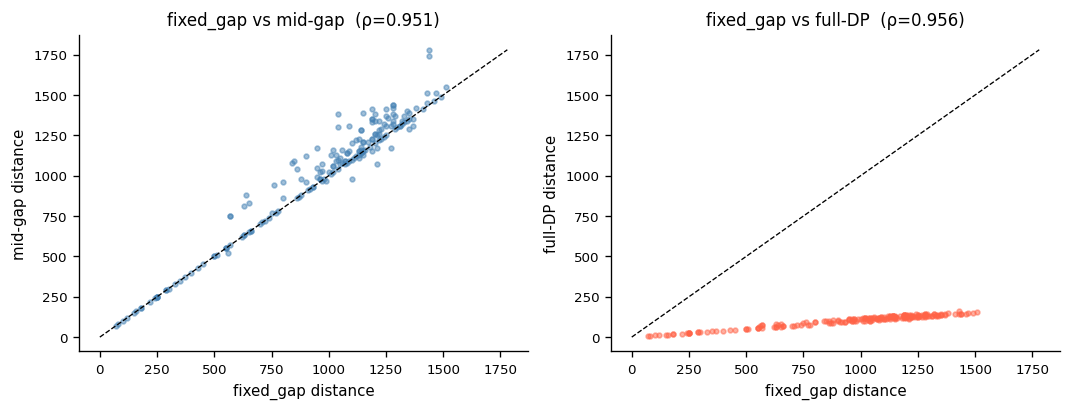

In [17]:
# Cell 17 — scatter matrix of gap mode distances
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
vmax = max(m_fg.max(), m_mid.max(), m_bio.max())

ax = axes[0]
ax.scatter(m_fg, m_mid, s=8, alpha=0.5, color="steelblue")
ax.plot([0, vmax], [0, vmax], "k--", lw=0.8)
ax.set_xlabel("fixed_gap distance")
ax.set_ylabel("mid-gap distance")
rho, _ = spearmanr(m_fg, m_mid)
ax.set_title(f"fixed_gap vs mid-gap  (ρ={rho:.3f})")

ax = axes[1]
ax.scatter(m_fg, m_bio, s=8, alpha=0.5, color="tomato")
ax.plot([0, vmax], [0, vmax], "k--", lw=0.8)
ax.set_xlabel("fixed_gap distance")
ax.set_ylabel("full-DP distance")
rho, _ = spearmanr(m_fg, m_bio)
ax.set_title(f"fixed_gap vs full-DP  (ρ={rho:.3f})")

fig.tight_layout()
plt.show()

## 10. Diagnostics Summary

In [18]:
# Cell 18 — summary
print("=" * 60)
print("TCRdist analysis summary")
print("=" * 60)
print(f"Clonotypes analysed : {N}")
print(f"Metaclonotypes found: {meta.n_clusters}")
print(f"Max cluster size    : {summary['n_members'].max()}")
print(f"Median radius (p50) : {np.median(radii):.2f}")
print(f"Distance range      : [{dist_mat[dist_mat>0].min():.1f}, {dist_mat.max():.1f}]")
print()
print("Models used:")
print(f"  V-gene scoring : full_germline (GermlineAligner.from_library)")
print(f"  CDR3 scoring   : JunctionAligner fixed_gaps=(3,4,-4,-3), gap_penalty=-4.0")
print(f"  Weights        : w_v={td.w_v}, w_j={td.w_j}, w_cdr3={td.w_cdr3}")
print("=" * 60)

TCRdist analysis summary
Clonotypes analysed : 100
Metaclonotypes found: 5236
Max cluster size    : 4040
Median radius (p50) : 2970.00
Distance range      : [480.0, 6120.0]

Models used:
  V-gene scoring : full_germline (GermlineAligner.from_library)
  CDR3 scoring   : JunctionAligner fixed_gaps=(3,4,-4,-3), gap_penalty=-4.0
  Weights        : w_v=1.0, w_j=0.0, w_cdr3=3.0
